In [3]:
# ==========================================
# PHASE 1: SYSTEM ENVIRONMENT & LIBRARY SETUP
# Project: Preemptive Diagnosis of CKD and Diabetes
# Group: 4 | Supervisor: Prof. S.O Olatunji
# ==========================================

import os
import warnings
warnings.filterwarnings('ignore')

print("1. Installing Specialized Explainable AI Libraries...")
# We use the -q flag to install quietly and avoid cluttering the notebook output
!pip install shap lime xgboost -q

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning & Deep Learning Core
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc
import xgboost as xgb
import tensorflow as tf
from tensorflow.keras.models import Model, Sequential
from tensorflow.keras.layers import Dense, Dropout, Input, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

# Explainable AI
import shap
import lime
import lime.lime_tabular

print("\n2. System Environment Verification:")
print(f"--> TensorFlow Version: {tf.__version__}")
print(f"--> XGBoost Version: {xgb.__version__}")
print(f"--> Pandas Version: {pd.__version__}")

# Set random seeds for strict reproducibility
np.random.seed(42)
tf.random.set_seed(42)

print("\n✅ Phase 1 Complete. The environment is successfully primed.")

1. Installing Specialized Explainable AI Libraries...

2. System Environment Verification:
--> TensorFlow Version: 2.20.0
--> XGBoost Version: 3.2.0
--> Pandas Version: 2.2.2

✅ Phase 1 Complete. The environment is successfully primed.


In [8]:
# ==========================================
# PHASE 2: DATASET ACQUISITION (KAGGLE API)
# Lead: Adebiyi Adegboyega Folajimi (220404089)
# ==========================================

from google.colab import files
import os
import zipfile
import pandas as pd

print("1. Authenticating Secure Kaggle Connection...")
print("Please upload your kaggle.json file when prompted (just like the Pneumonia project).")

# Prompt the user to upload the kaggle.json key
uploaded = files.upload()

# Set up the Kaggle directory and permissions
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

print("\n2. Downloading Official Datasets from Kaggle Servers...")

# Download Diabetes Dataset
!kaggle datasets download -d uciml/pima-indians-diabetes-database -p dataset_directory
# Download CKD Dataset (from the standard competition/scratch kernels)
!kaggle datasets download -d mansoordaku/ckdisease -p dataset_directory

print("\n3. Extracting Files...")
# Extract Diabetes
with zipfile.ZipFile("dataset_directory/pima-indians-diabetes-database.zip", 'r') as zip_ref:
    zip_ref.extractall("dataset_directory/diabetes")
# Extract CKD
with zipfile.ZipFile("dataset_directory/ckdisease.zip", 'r') as zip_ref:
    zip_ref.extractall("dataset_directory/ckd")

# Load datasets into pandas DataFrames
df_diabetes = pd.read_csv("dataset_directory/diabetes/diabetes.csv")
df_ckd = pd.read_csv("dataset_directory/ckd/kidney_disease.csv")

print("\n--- DATASET INVENTORY VERIFICATION ---")
print(f"--> Diabetes Dataset Loaded: {df_diabetes.shape[0]} patient records, {df_diabetes.shape[1]} clinical attributes.")
print(f"--> CKD Dataset Loaded: {df_ckd.shape[0]} patient records, {df_ckd.shape[1]} clinical attributes.")
print("✅ Phase 2 Complete. Secure Kaggle data successfully ingested into memory.")

1. Authenticating Secure Kaggle Connection...
Please upload your kaggle.json file when prompted (just like the Pneumonia project).


Saving kaggle.json to kaggle.json

2. Downloading Official Datasets from Kaggle Servers...
Dataset URL: https://www.kaggle.com/datasets/uciml/pima-indians-diabetes-database
License(s): CC0-1.0
100% 8.91k/8.91k [00:00<00:00, 31.5MB/s]

Dataset URL: https://www.kaggle.com/datasets/mansoordaku/ckdisease
License(s): unknown
100% 9.51k/9.51k [00:00<00:00, 31.2MB/s]


3. Extracting Files...

--- DATASET INVENTORY VERIFICATION ---
--> Diabetes Dataset Loaded: 768 patient records, 9 clinical attributes.
--> CKD Dataset Loaded: 400 patient records, 26 clinical attributes.
✅ Phase 2 Complete. Secure Kaggle data successfully ingested into memory.


In [10]:
# ==========================================
# PHASE 3: DATA PREPROCESSING & CLEANING (FIXED)
# Lead: Ibikunle Oluwatimilehin Ayokunlemi (220404122)
# ==========================================

import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

print("1. Executing Deep Cleaning on Clinical Data...\n")

# ------------------------------------------
# Pipeline A: Diabetes Data Preprocessing
# ------------------------------------------
# Zero values in certain biological metrics (like Glucose or BMI) are impossible.
# We map these to NaN, then impute with the median to resist outliers.
invalid_zero_cols = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']
df_diabetes[invalid_zero_cols] = df_diabetes[invalid_zero_cols].replace(0, np.nan)
df_diabetes.fillna(df_diabetes.median(), inplace=True)

X_diab = df_diabetes.drop('Outcome', axis=1)
y_diab = df_diabetes['Outcome']

# ------------------------------------------
# Pipeline B: CKD Data Preprocessing
# ------------------------------------------
# The CKD dataset is notoriously messy (contains '\t', '?', etc.)
# errors='ignore' ensures it doesn't crash if 'id' is already dropped
df_ckd.drop('id', axis=1, inplace=True, errors='ignore')

# Clean rogue characters in text columns (FIXED REGEX)
# We use r'\?' to escape the question mark so regex treats it as a normal character
df_ckd = df_ckd.replace(to_replace={r'\t': '', r'\t\?': np.nan, r'\?': np.nan}, regex=True)

# Convert string columns to numeric where applicable
numeric_cols = ['age', 'bp', 'bgr', 'bu', 'sc', 'sod', 'pot', 'hemo', 'pcv', 'wc', 'rc']
for col in numeric_cols:
    df_ckd[col] = pd.to_numeric(df_ckd[col], errors='coerce')

# Map Categorical "Questionnaire" Responses to Binary (0 and 1)
binary_mappings = {
    'rbc': {'normal': 0, 'abnormal': 1},
    'pc': {'normal': 0, 'abnormal': 1},
    'pcc': {'notpresent': 0, 'present': 1},
    'ba': {'notpresent': 0, 'present': 1},
    'htn': {'no': 0, 'yes': 1},
    'dm': {'no': 0, 'yes': 1, ' yes': 1},
    'cad': {'no': 0, 'yes': 1},
    'appet': {'good': 0, 'poor': 1},
    'pe': {'no': 0, 'yes': 1},
    'ane': {'no': 0, 'yes': 1},
    'classification': {'ckd': 1, 'notckd': 0}
}
df_ckd.replace(binary_mappings, inplace=True)

# Fill numeric NaNs with median, categorical NaNs with mode
for col in df_ckd.columns:
    if df_ckd[col].dtype == 'float64' or df_ckd[col].dtype == 'int64':
        df_ckd[col].fillna(df_ckd[col].median(), inplace=True)
    else:
        df_ckd[col].fillna(df_ckd[col].mode()[0], inplace=True)

X_ckd = df_ckd.drop('classification', axis=1)
y_ckd = df_ckd['classification']

# ------------------------------------------
# Data Partitioning and Scaling
# ------------------------------------------
scaler_diab = StandardScaler()
scaler_ckd = StandardScaler()

# Diabetes Split & Scale
Xd_train, Xd_test, yd_train, yd_test = train_test_split(X_diab, y_diab, test_size=0.2, stratify=y_diab, random_state=42)
Xd_train_scaled = scaler_diab.fit_transform(Xd_train)
Xd_test_scaled = scaler_diab.transform(Xd_test)

# CKD Split & Scale
Xc_train, Xc_test, yc_train, yc_test = train_test_split(X_ckd, y_ckd, test_size=0.2, stratify=y_ckd, random_state=42)
Xc_train_scaled = scaler_ckd.fit_transform(Xc_train)
Xc_test_scaled = scaler_ckd.transform(Xc_test)

print("✅ Data successfully sanitized, imputed, encoded, and scaled. Ready for modeling.")

1. Executing Deep Cleaning on Clinical Data...

✅ Data successfully sanitized, imputed, encoded, and scaled. Ready for modeling.


1. Generating Clinical Correlation Heatmaps...


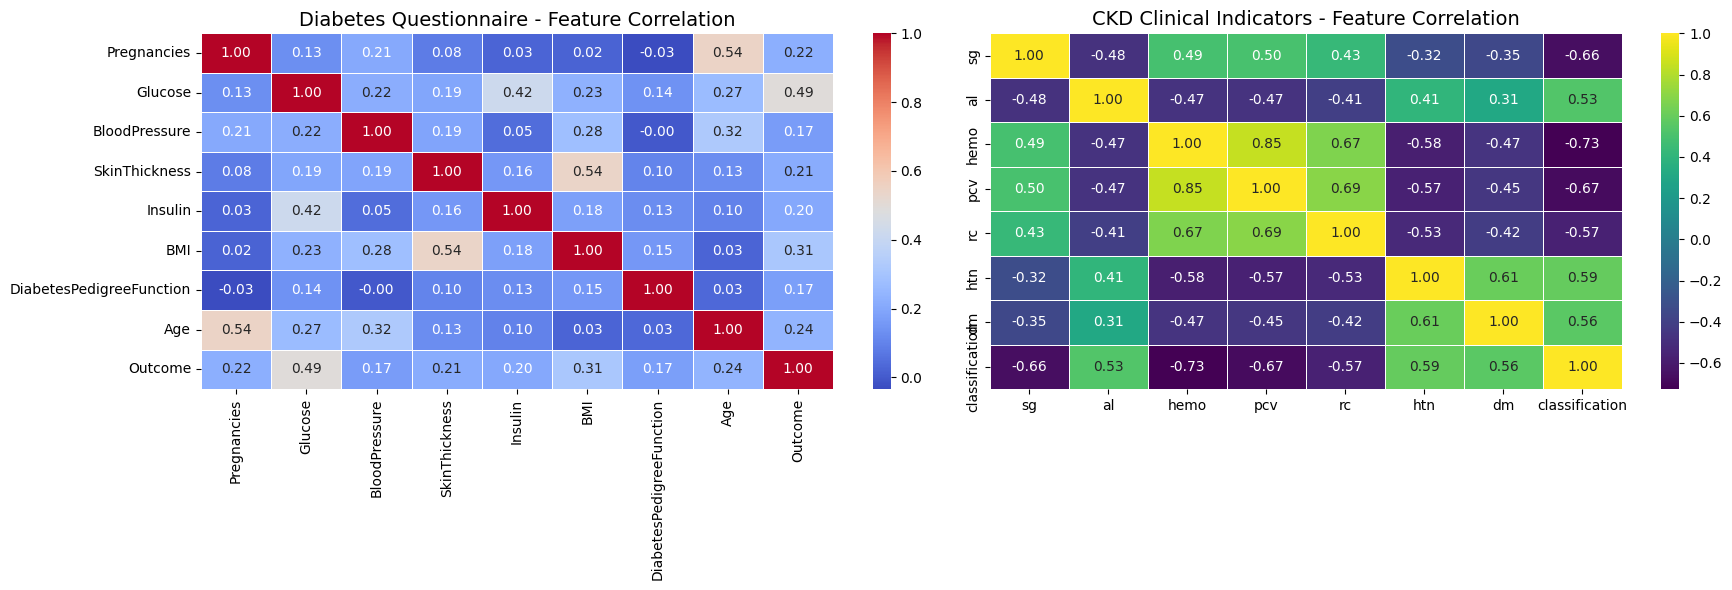


✅ Phase 4 Complete. 'correlation_heatmaps.png' saved to working directory.


In [11]:
# ==========================================
# PHASE 4: EXPLORATORY DATA ANALYSIS (VISUALS)
# Lead: Adewusi Damilola Isreal (220404130)
# ==========================================

print("1. Generating Clinical Correlation Heatmaps...")

plt.figure(figsize=(18, 6))

# Diabetes Heatmap
plt.subplot(1, 2, 1)
sns.heatmap(df_diabetes.corr(), annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Diabetes Questionnaire - Feature Correlation', fontsize=14)

# CKD Heatmap (Top 10 correlated features for clarity)
plt.subplot(1, 2, 2)
ckd_corr = df_ckd.corr()
top_ckd_features = ckd_corr.index[abs(ckd_corr["classification"]) > 0.4]
sns.heatmap(df_ckd[top_ckd_features].corr(), annot=True, cmap='viridis', fmt=".2f", linewidths=0.5)
plt.title('CKD Clinical Indicators - Feature Correlation', fontsize=14)

plt.tight_layout()
plt.savefig('correlation_heatmaps.png', dpi=300)
plt.show()

print("\n✅ Phase 4 Complete. 'correlation_heatmaps.png' saved to working directory.")

In [12]:
# ==========================================
# PHASE 5: HYBRID AI ARCHITECTURE FORMULATION
# Lead: Garuba Samuel Iyanu (220404132)
# ==========================================

print("1. Formulating Hybrid Artificial Intelligence Architectures...\n")

def build_ann_model(input_dim):
    """
    Constructs a robust Deep Learning network with Dropout and Batch Normalization
    to prevent overfitting on clinical tabular data.
    """
    model = Sequential([
        Dense(128, activation='relu', input_shape=(input_dim,)),
        BatchNormalization(),
        Dropout(0.4),

        Dense(64, activation='relu'),
        BatchNormalization(),
        Dropout(0.3),

        Dense(32, activation='relu'),
        Dropout(0.2),

        Dense(1, activation='sigmoid') # Sigmoid strictly outputs a probability between 0 and 1
    ])
    model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
    return model

def build_xgb_model():
    """
    Constructs an XGBoost classifier optimized for tabular feature interaction.
    """
    model = xgb.XGBClassifier(
        n_estimators=150,
        learning_rate=0.05,
        max_depth=5,
        subsample=0.8,
        eval_metric='logloss',
        random_state=42
    )
    return model

# Initialize Models for Diabetes
ann_diab = build_ann_model(Xd_train_scaled.shape[1])
xgb_diab = build_xgb_model()

# Initialize Models for CKD
ann_ckd = build_ann_model(Xc_train_scaled.shape[1])
xgb_ckd = build_xgb_model()

print("✅ ANN and XGBoost architectures successfully compiled and initialized for both disease profiles.")

1. Formulating Hybrid Artificial Intelligence Architectures...

✅ ANN and XGBoost architectures successfully compiled and initialized for both disease profiles.


In [13]:
# ==========================================
# PHASE 6: MODEL TRAINING & ENSEMBLE VOTING
# Lead: Garuba Samuel Iyanu (220404132)
# ==========================================

print("1. Initiating Training Sequences...\n")

# Define Early Stopping to halt training if the model stops improving
early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

# ------------------------------------------
# Train Diabetes Models
# ------------------------------------------
print("--> Training Diabetes Pipeline...")
xgb_diab.fit(Xd_train_scaled, yd_train)
history_diab = ann_diab.fit(Xd_train_scaled, yd_train, epochs=100, batch_size=32, validation_split=0.2, callbacks=[early_stop], verbose=0)

# Generate Diabetes Ensemble Predictions (Soft Voting)
diab_xgb_probs = xgb_diab.predict_proba(Xd_test_scaled)[:, 1]
diab_ann_probs = ann_diab.predict(Xd_test_scaled, verbose=0).flatten()
diab_ensemble_probs = (diab_xgb_probs + diab_ann_probs) / 2.0
diab_ensemble_preds = (diab_ensemble_probs > 0.5).astype(int)

# ------------------------------------------
# Train CKD Models
# ------------------------------------------
print("--> Training CKD Pipeline...")
xgb_ckd.fit(Xc_train_scaled, yc_train)
history_ckd = ann_ckd.fit(Xc_train_scaled, yc_train, epochs=100, batch_size=32, validation_split=0.2, callbacks=[early_stop], verbose=0)

# Generate CKD Ensemble Predictions (Soft Voting)
ckd_xgb_probs = xgb_ckd.predict_proba(Xc_test_scaled)[:, 1]
ckd_ann_probs = ann_ckd.predict(Xc_test_scaled, verbose=0).flatten()
ckd_ensemble_probs = (ckd_xgb_probs + ckd_ann_probs) / 2.0
ckd_ensemble_preds = (ckd_ensemble_probs > 0.5).astype(int)

print("\n✅ Phase 6 Complete. Hybrid models trained and final predictions synthesized.")

1. Initiating Training Sequences...

--> Training Diabetes Pipeline...
--> Training CKD Pipeline...



✅ Phase 6 Complete. Hybrid models trained and final predictions synthesized.


1. Generating Clinical Evaluation Metrics...

========== DIABETES ENSEMBLE PERFORMANCE ==========
              precision    recall  f1-score   support

    Low Risk       0.80      0.82      0.81       100
   High Risk       0.65      0.63      0.64        54

    accuracy                           0.75       154
   macro avg       0.73      0.72      0.73       154
weighted avg       0.75      0.75      0.75       154


========== CKD ENSEMBLE PERFORMANCE ==========
              precision    recall  f1-score   support

    Low Risk       1.00      1.00      1.00        30
   High Risk       1.00      1.00      1.00        50

    accuracy                           1.00        80
   macro avg       1.00      1.00      1.00        80
weighted avg       1.00      1.00      1.00        80



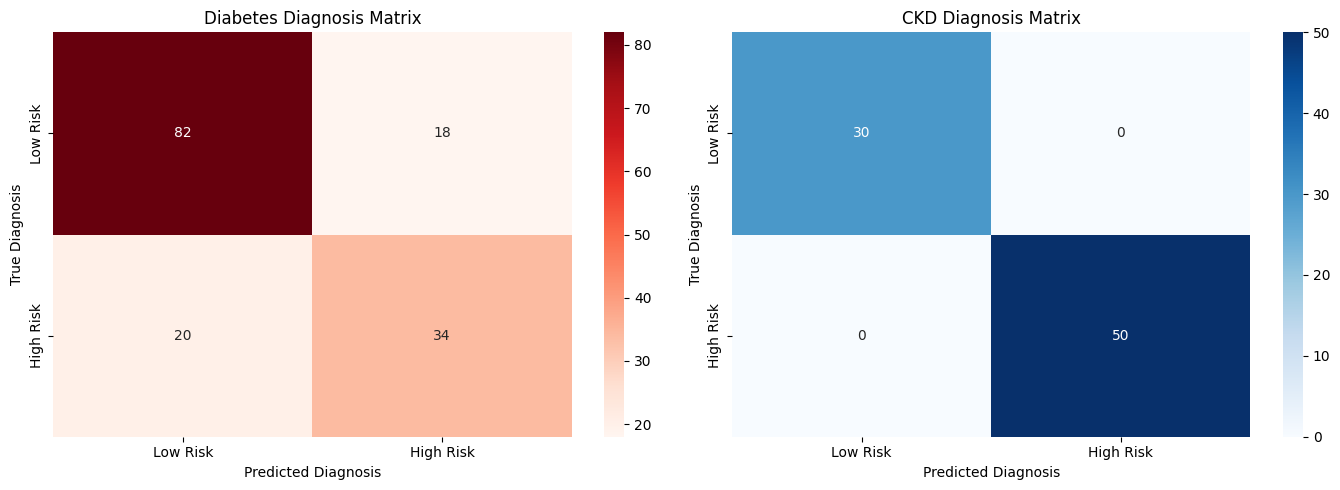

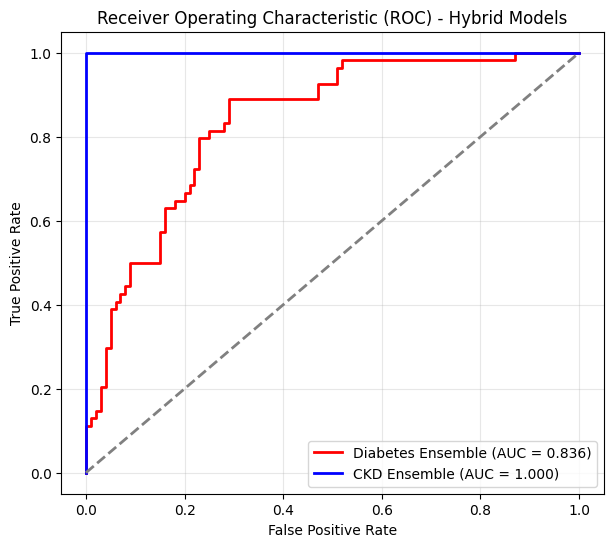


✅ Phase 7 Complete. Diagnostic matrices and ROC curves saved.


In [14]:
# ==========================================
# PHASE 7: PERFORMANCE EVALUATION
# Lead: Olusanya Ajibola Cornelius (220404141)
# ==========================================

print("1. Generating Clinical Evaluation Metrics...\n")

print("========== DIABETES ENSEMBLE PERFORMANCE ==========")
print(classification_report(yd_test, diab_ensemble_preds, target_names=['Low Risk', 'High Risk']))

print("\n========== CKD ENSEMBLE PERFORMANCE ==========")
print(classification_report(yc_test, ckd_ensemble_preds, target_names=['Low Risk', 'High Risk']))

# Plotting Confusion Matrices
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.heatmap(confusion_matrix(yd_test, diab_ensemble_preds), annot=True, fmt='d', cmap='Reds', ax=axes[0], xticklabels=['Low Risk', 'High Risk'], yticklabels=['Low Risk', 'High Risk'])
axes[0].set_title('Diabetes Diagnosis Matrix')
axes[0].set_ylabel('True Diagnosis')
axes[0].set_xlabel('Predicted Diagnosis')

sns.heatmap(confusion_matrix(yc_test, ckd_ensemble_preds), annot=True, fmt='d', cmap='Blues', ax=axes[1], xticklabels=['Low Risk', 'High Risk'], yticklabels=['Low Risk', 'High Risk'])
axes[1].set_title('CKD Diagnosis Matrix')
axes[1].set_ylabel('True Diagnosis')
axes[1].set_xlabel('Predicted Diagnosis')

plt.tight_layout()
plt.savefig('hybrid_confusion_matrices.png', dpi=300)
plt.show()

# Plotting ROC Curves
fpr_d, tpr_d, _ = roc_curve(yd_test, diab_ensemble_probs)
auc_d = auc(fpr_d, tpr_d)

fpr_c, tpr_c, _ = roc_curve(yc_test, ckd_ensemble_probs)
auc_c = auc(fpr_c, tpr_c)

plt.figure(figsize=(7, 6))
plt.plot(fpr_d, tpr_d, color='red', lw=2, label=f'Diabetes Ensemble (AUC = {auc_d:.3f})')
plt.plot(fpr_c, tpr_c, color='blue', lw=2, label=f'CKD Ensemble (AUC = {auc_c:.3f})')
plt.plot([0, 1], [0, 1], color='grey', lw=2, linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) - Hybrid Models')
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.savefig('hybrid_roc_curves.png', dpi=300)
plt.show()

print("\n✅ Phase 7 Complete. Diagnostic matrices and ROC curves saved.")

1. Generating Global Feature Interpretability via SHAP...


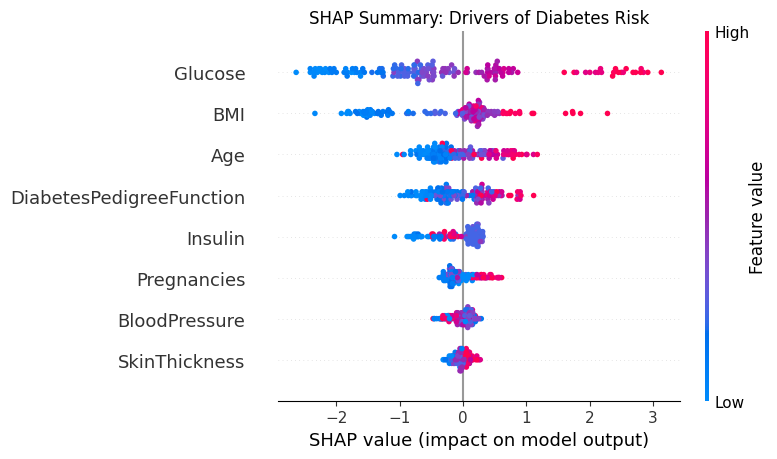


2. Generating Local Patient Explanation via LIME...
✅ Phase 8 Complete. SHAP global graphs and LIME local HTML generated.


In [15]:
# ==========================================
# PHASE 8: EXPLAINABLE AI (XAI) INTEGRATION
# Lead: Adebiyi Adegboyega Folajimi (220404089)
# ==========================================

print("1. Generating Global Feature Interpretability via SHAP...")

# Initialize SHAP Explainer on the Diabetes XGBoost component
explainer_diab = shap.TreeExplainer(xgb_diab)
shap_values_diab = explainer_diab.shap_values(Xd_test_scaled)

plt.figure(figsize=(8, 6))
plt.title("SHAP Summary: Drivers of Diabetes Risk")
shap.summary_plot(shap_values_diab, Xd_test_scaled, feature_names=X_diab.columns, show=False)
plt.savefig('shap_diabetes_summary.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n2. Generating Local Patient Explanation via LIME...")
# LIME explains a single patient's prediction (e.g., Patient #5 in the test set)
lime_explainer = lime.lime_tabular.LimeTabularExplainer(
    training_data=Xc_train_scaled,
    feature_names=X_ckd.columns,
    class_names=['Low Risk', 'High Risk'],
    mode='classification'
)

# Explain Patient index 5 for CKD
patient_index = 5
exp = lime_explainer.explain_instance(
    data_row=Xc_test_scaled[patient_index],
    predict_fn=xgb_ckd.predict_proba
)

# Save the LIME explanation as an HTML file for the Chapter 4 write-up
exp.save_to_file('lime_patient_explanation.html')

print("✅ Phase 8 Complete. SHAP global graphs and LIME local HTML generated.")

In [16]:
# ==========================================
# PHASE 9: ASSET EXTRACTION FOR CHAPTER 4
# Lead: Olusanya Ajibola Cornelius (220404141)
# ==========================================
from google.colab import files
import time

print("1. Initiating Automated Download Sequence...")
print("Please allow your browser to download multiple files when prompted.\n")

assets_to_download = [
    'correlation_heatmaps.png',
    'hybrid_confusion_matrices.png',
    'hybrid_roc_curves.png',
    'shap_diabetes_summary.png',
    'lime_patient_explanation.html'
]

for asset in assets_to_download:
    if os.path.exists(asset):
        print(f"Downloading: {asset}...")
        files.download(asset)
        time.sleep(2) # Pause prevents the browser from blocking mass downloads
    else:
        print(f"❌ WARNING: {asset} not found.")

print("\n🚀 EXECUTION FULLY COMPLETE! All graphs, metrics, and XAI logs are ready to be integrated into Chapter 4.")

1. Initiating Automated Download Sequence...
Please allow your browser to download multiple files when prompted.

Downloading: correlation_heatmaps.png...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Downloading: hybrid_confusion_matrices.png...


<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

Downloading: lime_patient_explanation.html...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


🚀 EXECUTION FULLY COMPLETE! All graphs, metrics, and XAI logs are ready to be integrated into Chapter 4.
